In [1]:
from moc.configs.config import get_config
from moc.utils.run_config import RunConfig
# from moc.models.mqf2.lightning_module import MQF2LightningModule
from moc.models.mixture.mixture_model import MixtureLightningModule
from moc.models.trainers.lightning_trainer import get_lightning_trainer
from moc.datamodules.real_datamodule import RealDataModule
from moc.metrics.metrics_computer import compute_coverage_indicator, compute_log_region_size
from moc.conformal.conformalizers import L_CP, HDR_H
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch
import pickle
import os

In [2]:
config = get_config()
config.device = 'cpu'
M = 100
alphas = torch.linspace(0, 1, M, device=config.device)

In [3]:
def ensemble_PIT(samples, y, components = 3):
        pca = PCA(n_components = components) #keeping 3 components by default
        pca.fit(samples.reshape(-1,len(y[0])))
        vectors = pca.components_ 
        pits = []
        for i in range(len(vectors)):
            u = torch.as_tensor(vectors[i], dtype=samples.dtype, device=samples.device)
            sample_proj = torch.matmul(samples, u) # 256,100,1
            y_proj = torch.matmul(y, u) #256,1
            sample_sorted = torch.sort(sample_proj)[0] #256,100 sort across the columns
            n = len(samples[0]) #100
            cdf_values = torch.searchsorted(sample_sorted, y_proj.unsqueeze(-1), side='right') / n #256,1
            pits.append(cdf_values)
        return torch.stack(pits)

def pce_per_dataset(config, data_group, data_name, seeds):
    rc = RunConfig(config, data_group, data_name)
    pce_over_seeds = []
    for seed in seeds:
        datamodule = RealDataModule(rc, seed=seed)
        p, q = datamodule.input_dim, datamodule.output_dim
        model = MixtureLightningModule(p,q)
        #model = MQF2LightningModule(p, q)
        trainer = get_lightning_trainer(rc)
        trainer.fit(model, datamodule)

        total_pits = []
        for x, y in datamodule.test_dataloader():
            x = x.to(config.device)
            y = y.to(config.device)
            dist = model.predict(x)
            samples = dist.sample((100,)).permute(1, 0, 2) #256,100,4
            c = min(y.shape[1], 3)
            pit_values = ensemble_PIT(samples, y, components = c) #shape (4,256,1)
            total_pits.append(pit_values)
        total_pits = torch.cat(total_pits, dim=1) #shape (n_components, number of test data points, 1)

        pces = []
        for d in range(total_pits.shape[0]):
            pits = total_pits[d].view(-1)  # shape: (N,)
            pits_sorted = pits.sort()[0]
            cdf_estimates = torch.searchsorted(pits_sorted, alphas, side='right') / pits_sorted.numel()
            pce = torch.mean(torch.abs(cdf_estimates - alphas)).item()
            pces.append(pce)
        pce_over_seeds.append(pces)
        # pits = total_pits[0].view(-1) #taking the first dimension only, shape (256,)
        # pits_sorted = pits.sort()[0]
        # cdf_estimates = torch.searchsorted(pits_sorted, alphas, side='right') / pits_sorted.numel() #shape (100,)
        # pce = torch.mean(torch.abs(cdf_estimates - alphas)).item()
        # pce_over_seeds.append(pce)
    return pce_over_seeds

In [ ]:
dataset_names = [
    # ['camehl', 'households'],
    #              ['mulan', 'scm20d'],
    #              ['mulan', 'rf2'],
    #              ['mulan', 'rf1'],
    #              ['mulan', 'scm1d'],
    #              ['feldman', 'meps_21'],
    #              ['feldman', 'meps_19'],
    #              ['feldman', 'meps_20'],
    #              ['feldman', 'house'],
    #              ['feldman', 'bio'],
    #              ['feldman', 'blog_data'],
                 ['del_barrio', 'calcofi'],
                 ['wang', 'taxi']
                 ]
seeds = [0, 42, 866, 12, 4]
pces_across_datasets = {}

for dataset in dataset_names:
    data_group, data_name = dataset
    print(f"Working on dataset {data_name}")
    pce_over_seeds = pce_per_dataset(config, data_group, data_name, seeds)
    pces_across_datasets[f'{data_name}'] = np.array(pce_over_seeds)

In [2]:
with open("pce_across_dataset.pkl", "rb") as f:
    pces = pickle.load(f)

In [11]:
datasets = list(pces.keys())
mean_pces = []
stderr_pces = []
for data in datasets:
    avg = pces[data].mean(axis=0)
    stderr = pces[data].std(axis=0, ddof = 1) / np.sqrt(pces[data].shape[0])
    mean_pces.append(avg)
    stderr_pces.append(stderr)

In [16]:
means = [
    np.array([arr[i] for arr in mean_pces if len(arr) > i])
    for i in range(3)
]
stderrs = [
    np.array([arr[i] for arr in stderr_pces if len(arr) > i])
    for i in range(3)
]

In [18]:
stderrs

[array([0.00276583, 0.00320345, 0.00744775, 0.00755538, 0.00837753,
        0.00353074, 0.00956032, 0.00614453, 0.00113997, 0.00050129,
        0.00063309]),
 array([0.0010815 , 0.00206451, 0.01206009, 0.00737667, 0.00422351,
        0.00421025, 0.00934299, 0.00796526, 0.00074237, 0.00297794,
        0.00090632]),
 array([0.00300147, 0.00073354, 0.00982953, 0.00429497, 0.00547519])]

In [19]:
datasets

['households',
 'scm20d',
 'rf2',
 'rf1',
 'scm1d',
 'meps_21',
 'meps_19',
 'meps_20',
 'house',
 'bio',
 'blog_data']

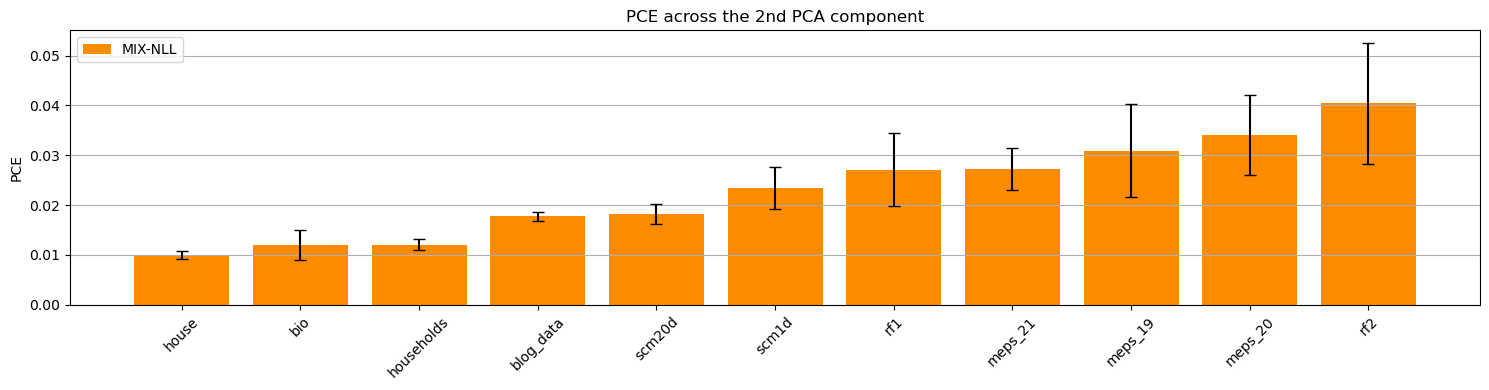

In [25]:
#plotting along PCAs
sorted_indices = np.argsort(means[1])
sorted_names = [datasets[i] for i in sorted_indices]
sorted_means = [means[1][i] for i in sorted_indices]
sorted_stderr = [stderrs[1][i] for i in sorted_indices]

# Step 3: Plot
x = np.arange(len(sorted_names))

plt.figure(figsize=(15, 4))
plt.bar(x, sorted_means, yerr=sorted_stderr, capsize=4, color='darkorange', label='MIX-NLL')
plt.xticks(x, sorted_names, rotation=45)
plt.ylabel("PCE")
plt.title("PCE across the 2nd PCA component")
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.savefig("figures/pce_d2.png", dpi=300, bbox_inches='tight')
plt.show()

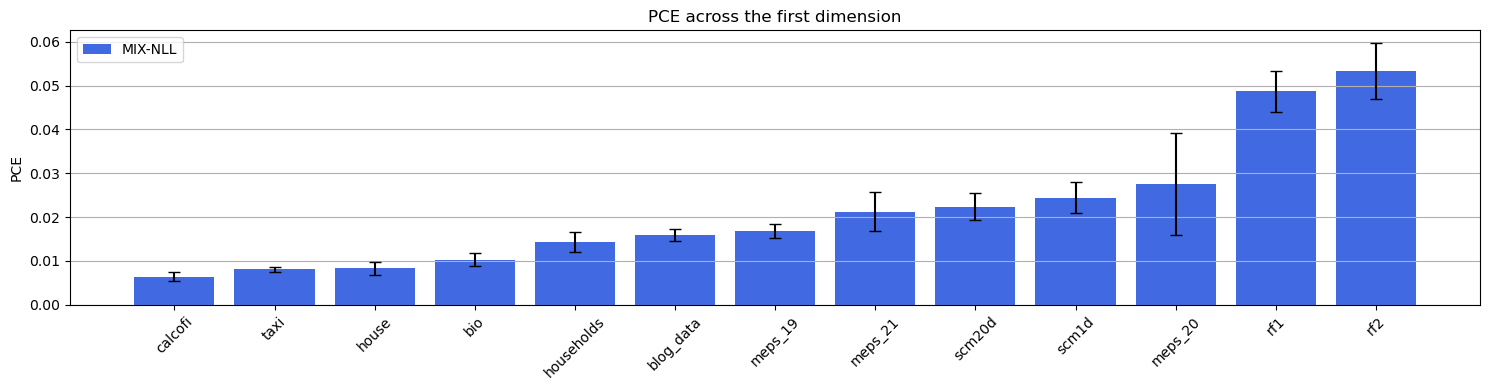

In [ ]:
dataset_names = list(pce_across_datasets.keys())
mean_pces = [np.mean(pce_across_datasets[name]) for name in dataset_names]
stderr_pces = [np.std(pce_across_datasets[name], ddof=1) / np.sqrt(5) for name in dataset_names]

# Step 2: Sort everything by mean PCE


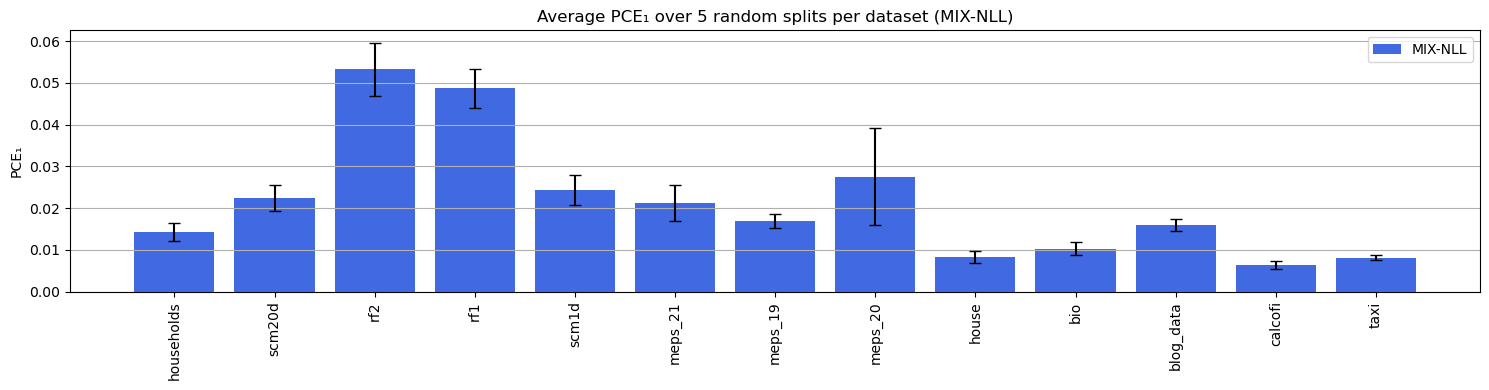

In [ ]:
# Sort dataset names alphabetically (or however you prefer)
dataset_names = pce_across_datasets.keys()

# Compute mean and standard error
mean_pces = [np.mean(pce_across_datasets[name]) for name in dataset_names]
stderr_pces = [np.std(pce_across_datasets[name], ddof=1) / np.sqrt(5) for name in dataset_names]

x = np.arange(len(dataset_names))

plt.figure(figsize=(15, 4))
plt.bar(x, mean_pces, yerr=stderr_pces, capsize=4, color='royalblue', label='MIX-NLL')
# plt.axhline(y=1/12, color='orange', linestyle='--', label='Perfect Calibration (PCE = 1/12)')
plt.xticks(x, dataset_names, rotation=90)
plt.ylabel("PCE")
plt.title("Average PCE over 5 random splits per dataset (MIX-NLL)")
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()